In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
d = pd.read_csv("/kaggle/input/datasets/bismasajjad/global-ai-job-market-and-salary-trends-2025/ai_job_dataset.csv")

In [3]:
d.columns

Index(['job_id', 'job_title', 'salary_usd', 'salary_currency',
       'experience_level', 'employment_type', 'company_location',
       'company_size', 'employee_residence', 'remote_ratio', 'required_skills',
       'education_required', 'years_experience', 'industry', 'posting_date',
       'application_deadline', 'job_description_length', 'benefits_score',
       'company_name'],
      dtype='object')

In [5]:
d.head()

,job_id,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name
0,AI00001,AI Research Scientist,90376,USD,SE,CT,China,M,China,50,"Tableau, PyTorch, Kubernetes, Linux, NLP",Bachelor,9,Automotive,2024-10-18,2024-11-07,1076,5.9,Smart Analytics
1,AI00002,AI Software Engineer,61895,USD,EN,CT,Canada,M,Ireland,100,"Deep Learning, AWS, Mathematics, Python, Docker",Master,1,Media,2024-11-20,2025-01-11,1268,5.2,TechCorp Inc
2,AI00003,AI Specialist,152626,USD,MI,FL,Switzerland,L,South Korea,0,"Kubernetes, Deep Learning, Java, Hadoop, NLP",Associate,2,Education,2025-03-18,2025-04-07,1974,9.4,Autonomous Tech
3,AI00004,NLP Engineer,80215,USD,SE,FL,India,M,India,50,"Scala, SQL, Linux, Python",PhD,7,Consulting,2024-12-23,2025-02-24,1345,8.6,Future Systems
4,AI00005,AI Consultant,54624,EUR,EN,PT,France,S,Singapore,100,"MLOps, Java, Tableau, Python",Master,0,Media,2025-04-15,2025-06-23,1989,6.6,Advanced Robotics


In [7]:
d['company_location'].value_counts()

company_location
Germany           814
Denmark           778
Canada            769
France            769
Austria           765
Singapore         764
China             763
India             754
Sweden            752
Israel            751
Ireland           750
Switzerland       746
Japan             733
Finland           733
Australia         732
Netherlands       731
United Kingdom    729
United States     724
South Korea       722
Norway            721
Name: count, dtype: int64

In [9]:
mean_sal = d.groupby("company_location")["salary_usd"].mean()

In [10]:
print(mean_sal)

company_location
Australia         118238.887978
Austria            85174.530719
Canada            114253.310793
China              84899.003932
Denmark           165652.249357
Finland            88726.242838
France            114411.361508
Germany           121810.143735
India              84236.051724
Ireland            86061.044000
Israel             86989.633822
Japan              86861.110505
Netherlands       126750.451436
Norway            159490.533981
Singapore         128004.035340
South Korea        85842.703601
Sweden            123559.753989
Switzerland       170639.085791
United Kingdom    128720.186557
United States     146833.045580
Name: salary_usd, dtype: float64


<Axes: xlabel='company_location'>

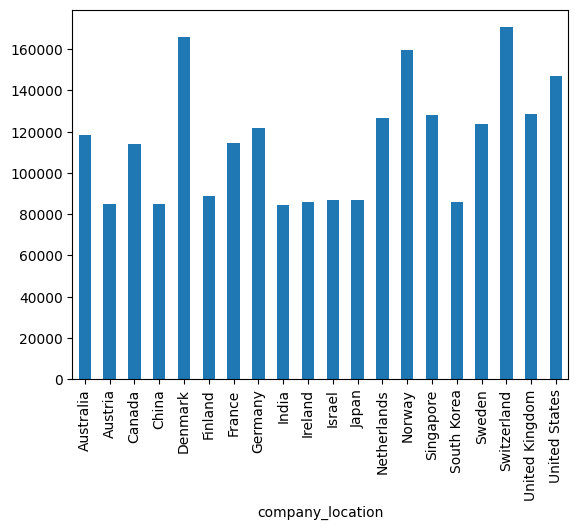

In [11]:
mean_sal.plot(kind="bar")

In [12]:
india_sal = d[d["company_location"] == "India"]["salary_usd"]

In [13]:
india_sal

3         80215
16        59823
46        46753
51       115376
56        79863
          ...  
14922     59649
14938     56095
14947     96629
14951     36376
14965     88191
Name: salary_usd, Length: 754, dtype: int64

In [14]:
np.random.choice(india_sal, size=50, replace=False)

array([ 54645,  89274,  98505, 157401,  46486, 172122,  48573, 120496,
        99539, 124640,  45917,  48262,  70336, 101009,  91410,  42927,
        38337, 128919,  79987,  63382,  80394,  65329,  62983,  36071,
        69991, 118413,  65866,  50932,  52008,  38334,  90770,  51758,
        48392,  40517,  38468, 102509,  63427,  50812,  82815,  67804,
        65293,  68278, 104276,  45821, 115496,  66533, 107933,  98101,
        62692,  58108])

In [16]:
sample_mean = []
for _ in range(10):
    sample = np.random.choice(india_sal, size = 50, replace=False)
    sample_mean.append(sample.mean())

In [17]:
print(sample_mean)

[np.float64(77164.54), np.float64(84184.48), np.float64(79359.94), np.float64(80552.92), np.float64(92768.18), np.float64(84361.5), np.float64(82500.32), np.float64(82070.4), np.float64(78979.86), np.float64(82781.9)]


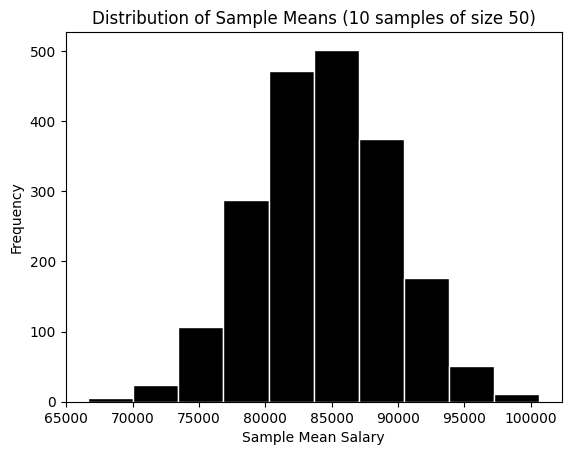

In [33]:
plt.hist(sample_mean, color='black',edgecolor='white')
plt.xlabel("Sample Mean Salary")
plt.ylabel("Frequency")
plt.title("Distribution of Sample Means (10 samples of size 50)")
plt.show()

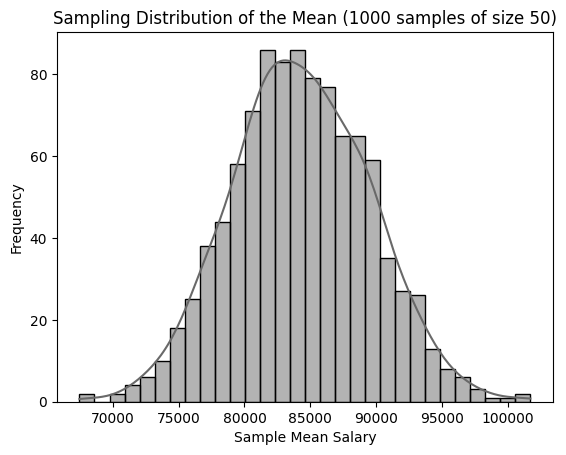

In [30]:
sample_means = []
for _ in range(1000):
    sample = np.random.choice(india_sal, size=50, replace=False)
    sample_means.append(np.mean(sample))

sns.histplot(sample_means, kde=True, bins=30, color="dimgray", edgecolor="black")
plt.xlabel("Sample Mean Salary")
plt.ylabel("Frequency")
plt.title("Sampling Distribution of the Mean (1000 samples of size 50)")
plt.show()